# RD random-tie sensitivity analysis

Attaches independent uniform labels to observed and control statistics and ranks statistic-label pairs lexicographically. It reports only the main rejection curve, main p-value distributions, and the complete placebo rejection curves across bandwidths.


In [1]:
from pathlib import Path
import sys


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src" / "cp_lfdr").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root containing src/cp_lfdr."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

# Edit DATA_DIR here if the data live outside the repository.
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
SEED = 0
SAVE_FIGURES = True
SAVE_TEX = True
RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    """Save a publication PDF and a high-resolution PNG.

    Set SAVE_FIGURES=False above to disable both. Set SAVE_TEX=True
    to additionally create a PGF-backed .tex file.
    """
    if not SAVE_FIGURES:
        return []
    paths = [
        FIGURE_DIR / f"{stem}.pdf",
        FIGURE_DIR / f"{stem}.png",
    ]
    fig.savefig(paths[0], bbox_inches="tight")
    fig.savefig(paths[1], bbox_inches="tight", dpi=300)
    if SAVE_TEX:
        tex_path = FIGURE_DIR / f"{stem}.tex"
        fig.savefig(tex_path, format="pgf", bbox_inches="tight")
        paths.append(tex_path)
    print(
        "Saved figure:",
        ", ".join(
            str(path.relative_to(PROJECT_ROOT)) for path in paths
        ),
    )
    return paths


from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdrobust import rdrobust

from cp_lfdr.discrete import (
    compute_discrete_gammas,
    gamma_from_block_pvalues,
)
from cp_lfdr.multiple_testing import bh_procedure, sl_procedure
from cp_lfdr.rd import (
    compute_pvalues_window,
    construct_year_specific_midpoint_base,
    filter_local_designs,
)
from IPython.display import display


def random_tie_broken_block_pvalues(block_matrix, rng):
    """Assign every pooled statistic a unique randomized upper-tail rank."""
    statistics = np.asarray(block_matrix, dtype=float)
    if not np.isfinite(statistics).all():
        raise ValueError("All pooled statistics must be finite.")
    labels = rng.random(statistics.shape)
    flat_statistics = statistics.ravel()
    flat_labels = labels.ravel()
    order = np.lexsort((flat_labels, flat_statistics))
    ascending_ranks = np.empty(len(order), dtype=int)
    ascending_ranks[order] = np.arange(1, len(order) + 1)
    upper_tail_ranks = len(order) - ascending_ranks + 1
    pvalues = upper_tail_ranks.reshape(statistics.shape) / len(order)
    assert np.unique(pvalues).size == pvalues.size
    return pvalues, labels


def compute_random_tie_broken_pvalues_window(
    *args, rng, alpha=0.01, return_structures=False, **kwargs
):
    """Run the existing analysis, then replace pooled ranks locally."""
    output = compute_pvalues_window(
        *args, rng=rng, alpha=alpha, return_structures=True, **kwargs
    )
    (
        results, _, sorted_pool, block_matrix, _, exact_statistics,
        observed_statistics,
    ) = output
    block_pvalues, tie_labels = random_tie_broken_block_pvalues(
        block_matrix, rng
    )
    results = results.copy()
    results["compound_p"] = block_pvalues[-1]
    gammas = compute_discrete_gammas(
        results["compound_p"].to_numpy(), block_pvalues, alpha
    )
    if not return_structures:
        return results, gammas
    return (
        results, gammas, sorted_pool, block_matrix, block_pvalues,
        exact_statistics, observed_statistics, tie_labels,
    )


def random_tie_broken_exact_compound_pvalues(
    exact_statistics, observed_statistics, rng
):
    """Pool exact tails after randomizing positions within tied blocks."""
    level_ids = list(observed_statistics)
    observed = np.asarray([observed_statistics[i] for i in level_ids])
    source_blocks = {}
    observed_labels = {}
    for level_id in level_ids:
        values = np.asarray(exact_statistics[level_id], dtype=float)
        labels = rng.random(len(values))
        # The first enumerated assignment is the observed left/right split.
        tolerance = max(
            1e-12,
            10 * np.finfo(float).eps
            * max(1.0, abs(float(observed_statistics[level_id]))),
        )
        assert abs(values[0] - observed_statistics[level_id]) <= tolerance
        order = np.argsort(values, kind="mergesort")
        source_blocks[level_id] = (values[order], labels[order])
        observed_labels[level_id] = labels[0]
    target_labels = np.asarray([observed_labels[i] for i in level_ids])
    tolerances = np.maximum(
        1e-12,
        10 * np.finfo(float).eps * np.maximum(1.0, np.abs(observed)),
    )
    tails = np.empty((len(level_ids), len(level_ids)), dtype=float)
    for row, source_id in enumerate(level_ids):
        values, labels = source_blocks[source_id]
        left = np.searchsorted(values, observed - tolerances, side="left")
        right = np.searchsorted(values, observed + tolerances, side="right")
        greater = len(values) - right
        tied_above = np.fromiter(
            (
                np.count_nonzero(labels[start:stop] >= target_label)
                for start, stop, target_label in zip(
                    left, right, target_labels
                )
            ),
            dtype=int, count=len(level_ids),
        )
        tails[row] = (greater + tied_above) / len(values)
    return pd.Series(
        tails.mean(axis=0), index=level_ids, name="exact_compound_p"
    )

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
})



## Main RD analysis


In [2]:
rd_path = DATA_DIR / "raw" / "rd" / "data-AER-3.dta"
if not rd_path.exists():
    raise FileNotFoundError(
        f"Missing {rd_path}. Follow data/README.md before running."
    )

rd_data = pd.read_stata(rd_path)
rd_data = rd_data.dropna(subset=["bcg"]).drop(columns=["survey"])
rd_data[["town", "z", "Y"]] = (
    rd_data["uazY"]
    .str.extract(r"(\d+)z(\d+)Y(\d+)")
    .astype(int)
)
rd_data["town_z"] = (
    rd_data["town"].astype(str) + "_" + rd_data["z"].astype(str)
)
rd_data["dzag"] = rd_data["dzag"].round(2)
rd_data = rd_data[rd_data["dzag"] != 0].copy()
print(f"Loaded {len(rd_data):,} student records.")


Loaded 6,165,081 student records.


In [3]:
bandwidth = 0.05
analysis_data = filter_local_designs(
    rd_data,
    level="town_z",
    distance_column="dzag",
    bandwidth=bandwidth,
    minimum_per_side=4,
    maximum_total=20,
)
print(
    f"{analysis_data['town_z'].nunique()} quasi-experiments "
    "remain after filtering."
)


345 quasi-experiments remain after filtering.


In [4]:
alpha = 0.2
dcp_draws = comb(8, 4)
# Each control is sampled independently, with replacement across draws.
# RandomState reproduces the legacy np.random.seed(0) stream.
rng = np.random.RandomState(SEED)
(
    rd_results,
    gammas,
    sorted_pool,
    block_matrix,
    block_pvalues,
    exact_statistics,
    observed_statistics,
    tie_labels,
) = compute_random_tie_broken_pvalues_window(
    analysis_data,
    "bcg",
    level="town_z",
    alpha=alpha,
    test_stat="welch_p",
    dcp_draws=dcp_draws,
    rng=rng,
    distance_column="dzag",
    bw_l=bandwidth,
    bw_r=bandwidth,
    gamma_hat=True,
    return_structures=True,
)
raw_duplicate_positions = (
    block_matrix.size - np.unique(block_matrix).size
)
print(
    f"Random tie-breaking resolved {raw_duplicate_positions:,} "
    "duplicate pooled-statistic positions."
)
gamma, gamma_minus, gamma_bh = gammas
print(
    f"gamma={gamma:.8f}, gamma_minus={gamma_minus:.8f}, "
    f"gamma_BH={gamma_bh:.8f}"
)
print(
    "SL rejections at alpha=0.2:",
    sl_procedure(rd_results["compound_p"], alpha)[1],
)
rd_results.nsmallest(10, "compound_p")


Random tie-breaking resolved 1,274 duplicate pooled-statistic positions.
gamma=0.32394366, gamma_minus=0.04225352, gamma_BH=0.04225352
SL rejections at alpha=0.2: 5


,town_z,local_p,compound_p
89,139820_2,0.003788,0.001551
87,13677_4,0.001166,0.001878
308,86829_11,0.004762,0.002368
225,51065_1,0.003584,0.002449
25,110072_4,0.003788,0.002735
136,156810_1,0.001998,0.005511
100,143691_1,0.014286,0.006940
76,13631_13,0.008204,0.009920
83,136606_1,0.008484,0.011431
234,55017_7,0.023810,0.014860


### Rejection curve


Saved figure: results/figures/rd_random_ties_rejection_curves.pdf, results/figures/rd_random_ties_rejection_curves.png, results/figures/rd_random_ties_rejection_curves.tex


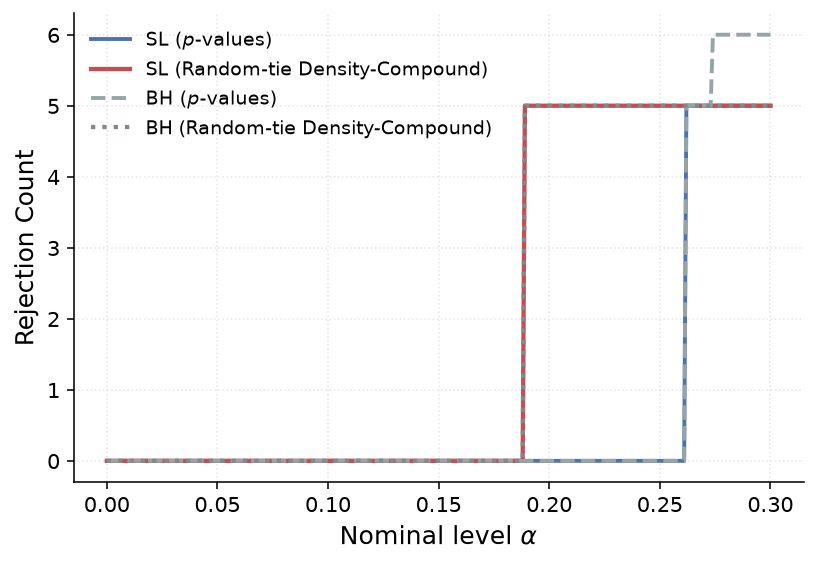

In [5]:
alpha_grid = np.arange(0, 0.301, 0.001)
p_values = rd_results["local_p"].to_numpy()
compound_pvalues = rd_results["compound_p"].to_numpy()
level_ids = list(observed_statistics)
exact_compound_pvalues = (
    random_tie_broken_exact_compound_pvalues(
        exact_statistics, observed_statistics, rng
    )
)
rejection_curve = pd.DataFrame(
    [
        {
            "alpha": level,
            "SL permutation": sl_procedure(p_values, level)[1],
            "SL permutation-DCP": sl_procedure(
                compound_pvalues,
                level,
            )[1],
            "BH permutation": bh_procedure(p_values, level)[1],
            "BH permutation-DCP": bh_procedure(
                compound_pvalues,
                level,
            )[1],
            "SL exact compound": sl_procedure(
                exact_compound_pvalues,
                level,
            )[1],
        }
        for level in alpha_grid
    ]
)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation"],
    color="#4C72B0",
    linestyle="-",
    linewidth=2.0,
    label=r"SL ($p$-values)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation-DCP"],
    color="#C44E52",
    linestyle="-",
    linewidth=2.2,
    label="SL (Random-tie Density-Compound)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["BH permutation"],
    color="#95a5a6",
    linestyle="--",
    linewidth=2.0,
    label=r"BH ($p$-values)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["BH permutation-DCP"],
    color="#7f8c8d",
    linestyle=":",
    linewidth=2.2,
    label="BH (Random-tie Density-Compound)",
)
ax.set_xlabel(r"Nominal level $\alpha$")
ax.set_ylabel("Rejection Count")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    color="#cccccc",
    zorder=0,
)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", fontsize="small")
fig.tight_layout()
_ = save_figure(fig, "rd_random_ties_rejection_curves")


### P-value distributions


Saved figure: results/figures/rd_random_ties_pvalue_histogram.pdf, results/figures/rd_random_ties_pvalue_histogram.png, results/figures/rd_random_ties_pvalue_histogram.tex


[PosixPath('/Users/jerryzhu/Documents/uchicago/projects/cp-lfdr/github-ready/results/figures/rd_random_ties_pvalue_histogram.pdf'),
 PosixPath('/Users/jerryzhu/Documents/uchicago/projects/cp-lfdr/github-ready/results/figures/rd_random_ties_pvalue_histogram.png'),
 PosixPath('/Users/jerryzhu/Documents/uchicago/projects/cp-lfdr/github-ready/results/figures/rd_random_ties_pvalue_histogram.tex')]

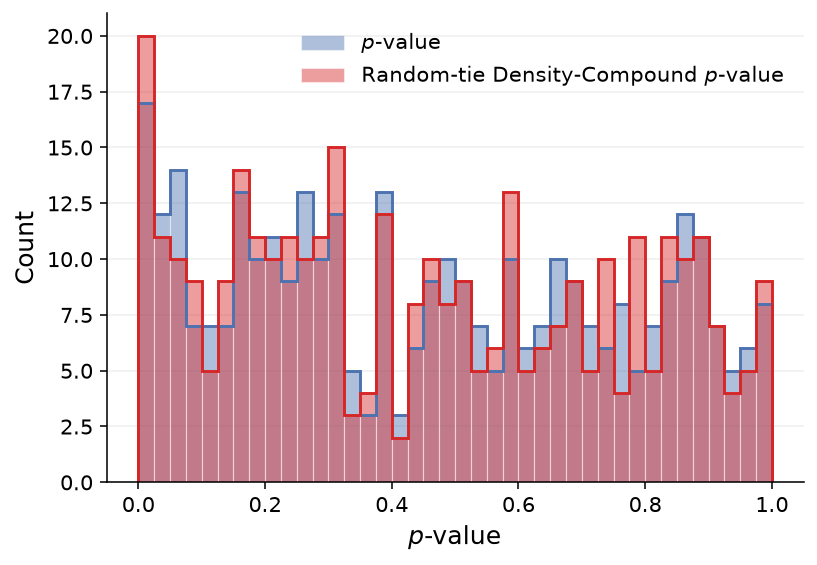

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.2))
bins = np.linspace(0, 1, 41)
ax.hist(
    p_values,
    bins=bins,
    alpha=0.45,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6,
    label=r"$p$-value",
)
ax.hist(
    compound_pvalues,
    bins=bins,
    alpha=0.45,
    color="#d62728",
    edgecolor="white",
    linewidth=0.6,
    label=r"Random-tie Density-Compound $p$-value",
)
ax.hist(
    p_values,
    bins=bins,
    histtype="step",
    color="#4C72B0",
    linewidth=1.5,
)
ax.hist(
    compound_pvalues,
    bins=bins,
    histtype="step",
    color="#d62728",
    linewidth=1.5,
)
ax.set_xlabel(r"$p$-value")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "rd_random_ties_pvalue_histogram")


## Midpoint-placebo rejection curves

For each bandwidth, the eligible placebo family and the 4/4/20 sample-size filters are reconstructed before applying SL. No town gallery or local-RD diagnostic plots are produced here.


In [7]:
rd_path = DATA_DIR / "raw" / "rd" / "data-AER-3.dta"
if not rd_path.exists():
    raise FileNotFoundError(
        f"Missing {rd_path}. Follow data/README.md before running."
    )

raw_rd_data = pd.read_stata(
    rd_path, columns=["dzag", "bcg", "uazY", "sid2"]
)
identifier_parts = raw_rd_data["uazY"].str.extract(
    r"(\d+)z(\d+)Y(\d+)"
)
identifier_parts.columns = ["town", "z", "Y"]
identifier_parts = identifier_parts.astype(int)
raw_rd_data[["town", "z", "Y"]] = identifier_parts
raw_rd_data["dzag"] = (
    raw_rd_data["dzag"].astype(float).round(2)
)
rd_data = raw_rd_data.dropna(subset=["bcg"]).copy()

cutoff_table, year_gap_table, midpoint_placebo_data = (
    construct_year_specific_midpoint_base(rd_data)
)
required_identifier_columns = {"z_low", "z_high", "placebo_id"}
missing_identifier_columns = (
    required_identifier_columns - set(year_gap_table.columns)
)
if missing_identifier_columns:
    raise RuntimeError(
        "The local cp_lfdr.rd module is out of date; missing columns: "
        + ", ".join(sorted(missing_identifier_columns))
    )

# The same construction cannot appear twice within one town-year.
assert not year_gap_table.duplicated(
    ["town", "Y", "z_low", "z_high"]
).any()
assert not midpoint_placebo_data.duplicated(
    ["placebo_id", "Y", "sid2"]
).any()

numeric_z_order = cutoff_table.sort_values(["town", "Y", "z"])
numeric_z_order["cutoff_increment"] = (
    numeric_z_order.groupby(["town", "Y"])["cutoff_position"].diff()
)
nonincreasing_numeric_z = int(
    (numeric_z_order["cutoff_increment"].dropna() <= 0).sum()
)
construction_audit = (
    year_gap_table.groupby("placebo_id", as_index=False)
    .agg(
        town=("town", "first"),
        z_low=("z_low", "first"),
        z_high=("z_high", "first"),
        available_years=("Y", "nunique"),
        distinct_gap_ranks=("gap_rank", "nunique"),
    )
)
audit = pd.Series({
    "towns": rd_data["town"].nunique(),
    "town-years": cutoff_table[["town", "Y"]].drop_duplicates().shape[0],
    "year-specific real cutoffs": len(cutoff_table),
    "year-specific candidate constructions": len(year_gap_table),
    "unique pooled placebo constructions": len(construction_audit),
    "constructions available in multiple years": int(
        (construction_audit["available_years"] > 1).sum()
    ),
    "constructions whose ordinal rank changes across years": int(
        (construction_audit["distinct_gap_ranks"] > 1).sum()
    ),
    "zero-width adjacent gaps": int((year_gap_table["gap_width"] == 0).sum()),
    "nonincreasing numeric-z steps": nonincreasing_numeric_z,
    "student-construction rows": len(midpoint_placebo_data),
})
display(audit.to_frame("count"))

print("Student-level and cutoff-table gap widths agree exactly.")
display(
    year_gap_table.sort_values(
        ["town", "Y", "left_cutoff_position"]
    ).head(12)
)

,count
towns,393
town-years,1024
year-specific real cutoffs,6433
year-specific candidate constructions,5409
unique pooled placebo constructions,3863
constructions available in multiple years,1194
constructions whose ordinal rank changes across years,527
zero-width adjacent gaps,238
nonincreasing numeric-z steps,1450
student-construction rows,5915108


Student-level and cutoff-table gap widths agree exactly.


,town,Y,gap_rank,z_left,left_cutoff_position,z_right,right_cutoff_position,gap_width,midpoint_position,z_low,z_high,placebo_id
0,1026,1,1,2,-2.545,1,-1.535,1.01,-2.040,1,2,1026_placebo1_2
1,1026,1,2,1,-1.535,3,-0.935,0.60,-1.235,1,3,1026_placebo1_3
2,1026,1,3,3,-0.935,4,-0.885,0.05,-0.910,3,4,1026_placebo3_4
3,1026,1,4,4,-0.885,6,-0.825,0.06,-0.855,4,6,1026_placebo4_6
4,1026,1,5,6,-0.825,5,-0.685,0.14,-0.755,5,6,1026_placebo5_6
5,1026,1,6,5,-0.685,7,-0.635,0.05,-0.660,5,7,1026_placebo5_7
6,1026,1,7,7,-0.635,8,-0.135,0.50,-0.385,7,8,1026_placebo7_8
7,1026,1,8,8,-0.135,9,-0.005,0.13,-0.070,8,9,1026_placebo8_9
8,1026,1,9,9,-0.005,10,0.005,0.01,0.000,9,10,1026_placebo9_10
9,1026,1,10,10,0.005,11,0.505,0.50,0.255,10,11,1026_placebo10_11


In [8]:
def filter_midpoint_placebo_design(
    placebo_data,
    *,
    bandwidth,
    level="placebo_id",
    distance_column="placebo_distance",
    year_column="Y",
    minimum_per_side=4,
    maximum_total=20,
    numerical_tolerance=1e-8,
):
    """Apply contamination, support, and pooled sample-size restrictions."""
    safe = placebo_data[
        placebo_data["gap_width"]
        > 2 * bandwidth + numerical_tolerance
    ].copy()

    # Mirror the main RD support check before restricting to the local window.
    support = (
        safe.groupby(level, as_index=False)[distance_column]
        .agg(_minimum_distance="min", _maximum_distance="max")
    )
    supported = support[
        (support["_minimum_distance"] <= -bandwidth + numerical_tolerance)
        & (support["_maximum_distance"] >= bandwidth - numerical_tolerance)
    ][[level]]
    safe = safe.merge(
        supported, on=level, how="inner", validate="many_to_one"
    )

    window = safe[
        (safe[distance_column].abs() <= bandwidth + numerical_tolerance)
        & (safe[distance_column].abs() > numerical_tolerance)
    ].copy()
    window["_is_left"] = window[distance_column] < 0
    window["_is_right"] = window[distance_column] > 0
    counts = (
        window.groupby(level, as_index=False)
        .agg(
            n_left=("_is_left", "sum"),
            n_right=("_is_right", "sum"),
            n_total=(distance_column, "size"),
            contributing_years=(year_column, "nunique"),
        )
    )
    retained = counts[
        (counts["n_left"] >= minimum_per_side)
        & (counts["n_right"] >= minimum_per_side)
        & (counts["n_total"] <= maximum_total)
    ].copy()
    sample = window.merge(
        retained[[level]], on=level, how="inner", validate="many_to_one"
    )
    return retained.reset_index(drop=True), sample


In [9]:
ALPHA = alpha
DCP_DRAWS = dcp_draws
NUMERICAL_TOLERANCE = 1e-8
MINIMUM_SIDE_COUNT = 4
MAXIMUM_TOTAL_COUNT = 20
BANDWIDTHS = [round(float(x), 2) for x in np.arange(0.01, 0.26, 0.01)]
ALPHA_GRID = alpha_grid


In [10]:
def compute_midpoint_results(sample, bandwidth):
    rng = np.random.RandomState(SEED)
    output = compute_random_tie_broken_pvalues_window(
        sample, "outcome", level="placebo_id", alpha=ALPHA,
        test_stat="welch_p", dcp_draws=DCP_DRAWS,
        rng=rng,
        distance_column="placebo_distance",
        bw_l=bandwidth, bw_r=bandwidth, return_structures=True,
    )
    results, exact_statistics, observed_statistics = (
        output[0], output[5], output[6]
    )
    results.attrs["raw_duplicate_positions"] = (
        output[3].size - np.unique(output[3]).size
    )
    exact_compound = random_tie_broken_exact_compound_pvalues(
        exact_statistics, observed_statistics, rng
    )
    results["exact_compound_p"] = results["placebo_id"].map(exact_compound)
    for column in ["local_p", "compound_p", "exact_compound_p"]:
        assert results[column].notna().all()
        assert (results[column] > 0).all()
    return results


def rejection_curve(results):
    return pd.DataFrame([{
        "alpha": level,
        "SL p-value": sl_procedure(results["local_p"].to_numpy(), level)[1],
        "SL Density-Compound": sl_procedure(
            results["compound_p"].to_numpy(), level
        )[1],
        "SL Compound": sl_procedure(
            results["exact_compound_p"].to_numpy(), level
        )[1],
    } for level in ALPHA_GRID])


,bandwidth,valid cohort-specific constructions,testable pooled placebo constructions,towns,median contributing cohorts,SL p-value,SL Density-Compound,SL Compound,minimum p-value,minimum Density-Compound,minimum Compound,raw duplicate pooled positions
0,0.01,4434,855,63,1.0,0,0,0,0.000333,0.001153,0.001180,4127
1,0.02,3889,736,102,1.0,0,0,0,0.005128,0.004325,0.004670,3163
2,0.03,3440,554,132,1.0,0,0,0,0.003239,0.002822,0.002362,2573
3,0.04,3047,502,146,1.0,0,0,0,0.001748,0.001683,0.001471,2353
4,0.05,2745,472,151,1.0,0,0,0,0.002198,0.010772,0.010567,1910
5,0.06,2489,419,155,1.0,0,1,1,0.002198,0.000101,0.000111,1650
6,0.07,2283,362,159,1.0,0,1,1,0.000654,0.000078,0.000036,1409
7,0.08,2093,329,153,1.0,0,0,0,0.010823,0.006850,0.006874,1300
8,0.09,1904,307,150,1.0,0,0,0,0.012277,0.004817,0.004483,1184
9,0.10,1744,265,148,1.0,0,0,0,0.010256,0.006112,0.006102,835


Saved figure: results/figures/rd_placebo_all_bandwidths_random_ties_rejection_curves.pdf, results/figures/rd_placebo_all_bandwidths_random_ties_rejection_curves.png, results/figures/rd_placebo_all_bandwidths_random_ties_rejection_curves.tex


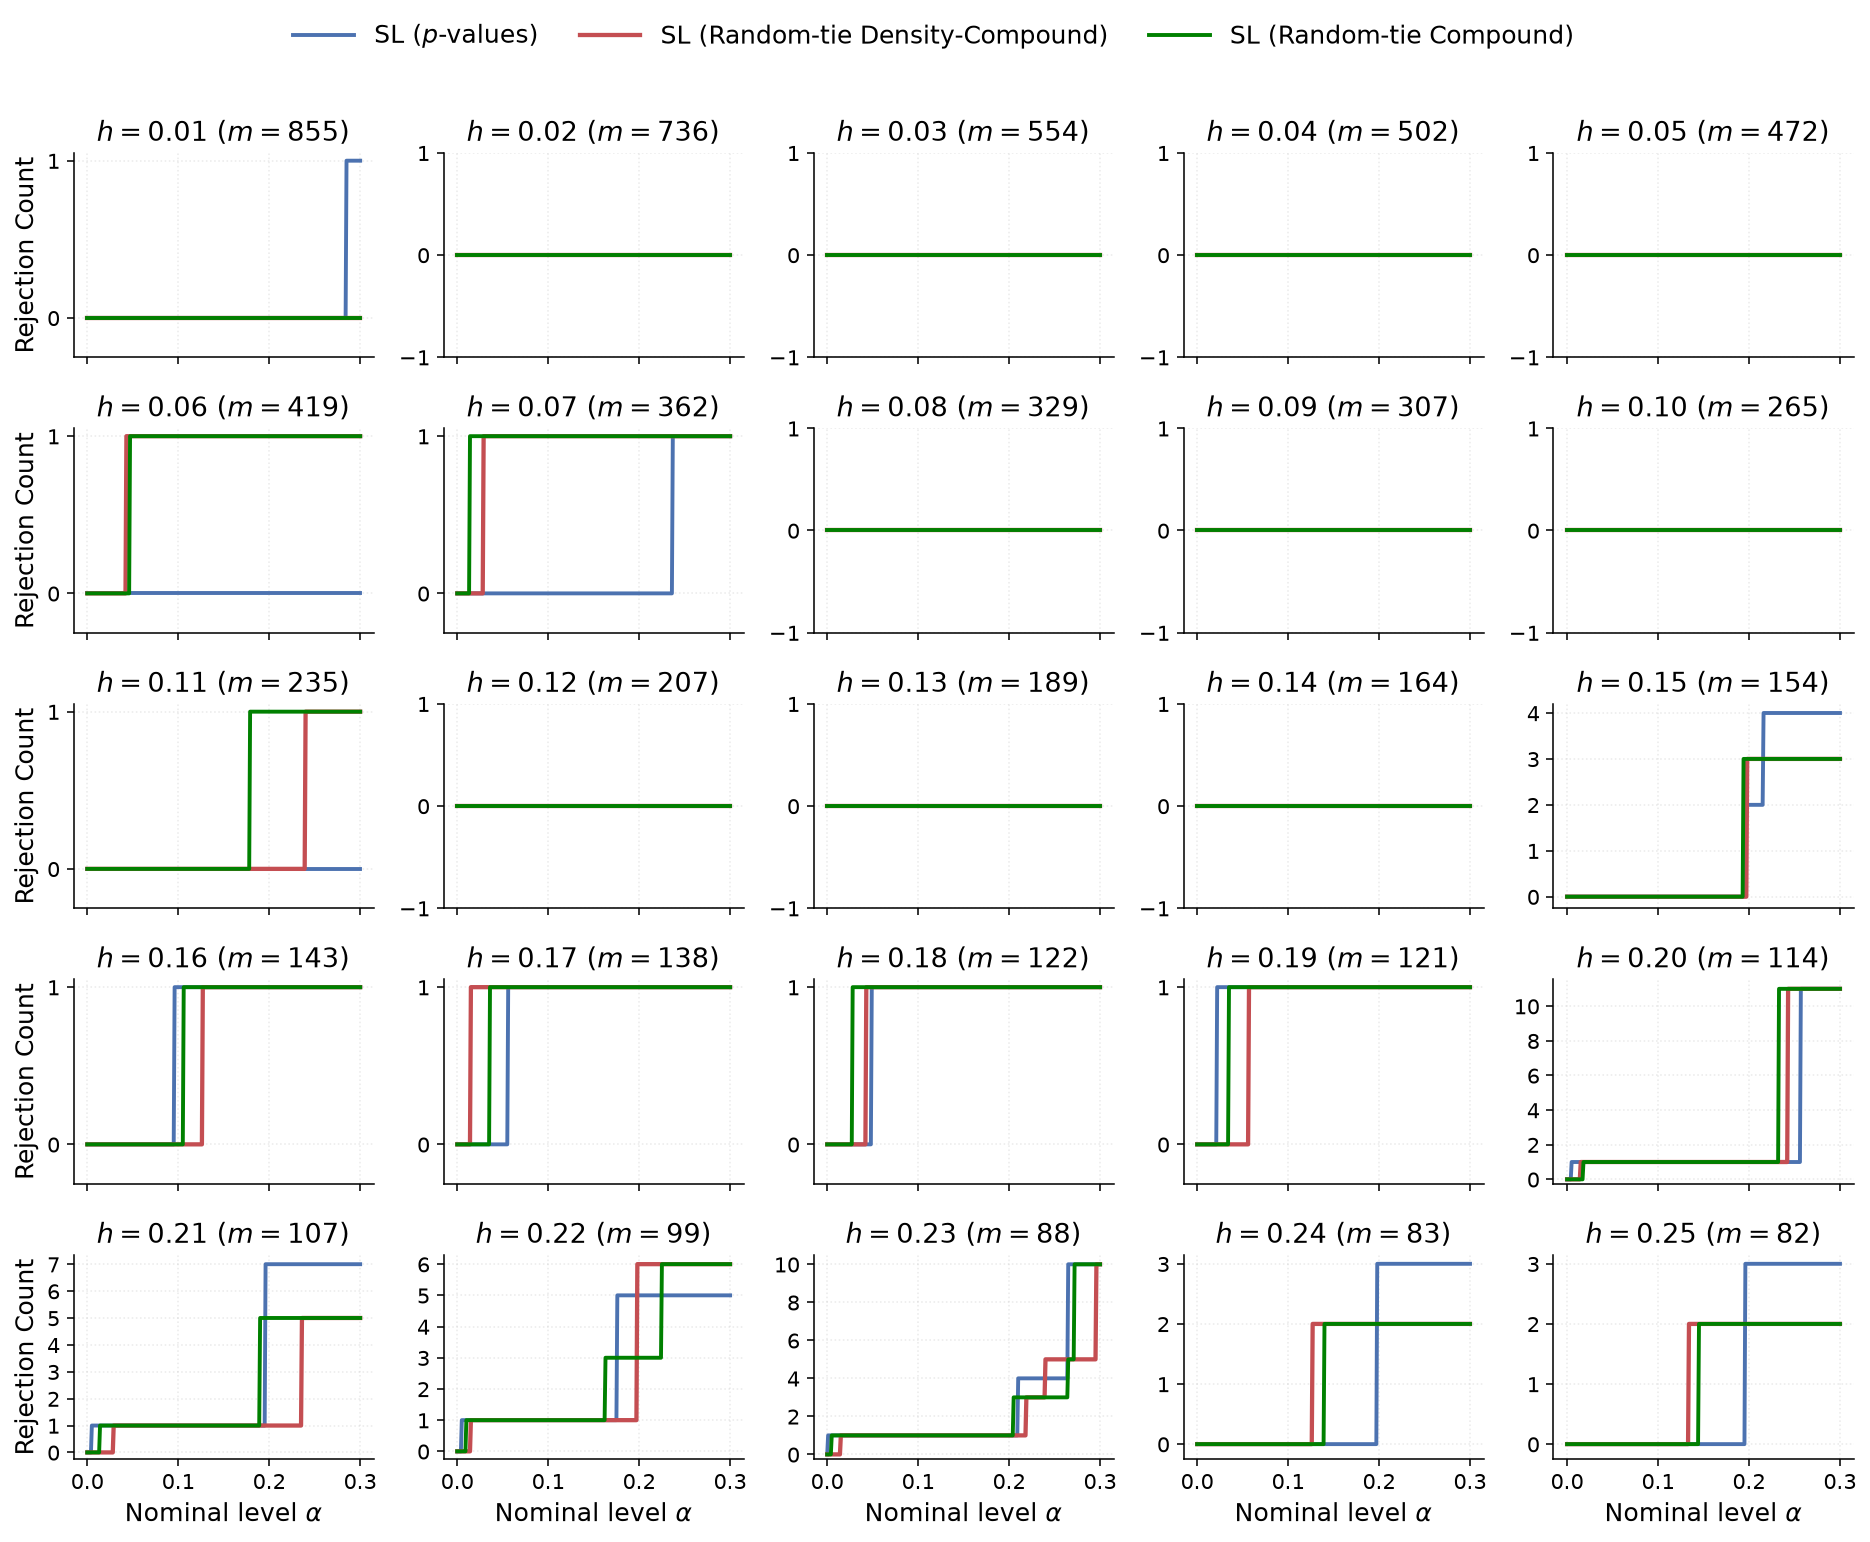

In [11]:
bandwidth_placebos = {}
bandwidth_samples = {}
bandwidth_results = {}
bandwidth_curves = {}
summary_rows = []
for bandwidth in BANDWIDTHS:
    retained, sample = filter_midpoint_placebo_design(
        midpoint_placebo_data, bandwidth=bandwidth,
        minimum_per_side=MINIMUM_SIDE_COUNT,
        maximum_total=MAXIMUM_TOTAL_COUNT,
    )
    results = compute_midpoint_results(sample, bandwidth)
    curve = rejection_curve(results)
    bandwidth_placebos[bandwidth] = retained
    bandwidth_samples[bandwidth] = sample
    bandwidth_results[bandwidth] = results
    bandwidth_curves[bandwidth] = curve
    row_at_alpha = curve.loc[np.isclose(curve["alpha"], ALPHA)].iloc[0]
    summary_rows.append({
        "bandwidth": bandwidth,
        "valid cohort-specific constructions": int(
            (year_gap_table["gap_width"]
             > 2 * bandwidth + NUMERICAL_TOLERANCE).sum()
        ),
        "testable pooled placebo constructions": len(results),
        "towns": sample["town"].nunique(),
        "median contributing cohorts": retained["contributing_years"].median(),
        "SL p-value": int(row_at_alpha["SL p-value"]),
        "SL Density-Compound": int(row_at_alpha["SL Density-Compound"]),
        "SL Compound": int(row_at_alpha["SL Compound"]),
        "minimum p-value": results["local_p"].min(),
        "minimum Density-Compound": results["compound_p"].min(),
        "minimum Compound": results["exact_compound_p"].min(),
        "raw duplicate pooled positions": (
            results.attrs["raw_duplicate_positions"]
        ),
    })
bandwidth_summary = pd.DataFrame(summary_rows)
display(bandwidth_summary)

# fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.2), sharex=True)
fig, axes = plt.subplots(5, 5, figsize=(13.5, 11.2), sharex=True)
for ax, bandwidth in zip(axes.flat, BANDWIDTHS):
    curve = bandwidth_curves[bandwidth]
    ax.plot(curve["alpha"], curve["SL p-value"], color="#4C72B0",
            linewidth=2, label=r"SL ($p$-values)")
    ax.plot(curve["alpha"], curve["SL Density-Compound"],
            color="#C44E52", linewidth=2.2,
            label="SL (Random-tie Density-Compound)")
    ax.plot(curve["alpha"], curve["SL Compound"], color="green",
            linewidth=2, label="SL (Random-tie Compound)")
    ax.set_title(rf"$h={bandwidth:.2f}$ "
                 rf"($m={len(bandwidth_results[bandwidth])}$)")
    maximum = int(curve.iloc[:, 1:].to_numpy().max())
    if maximum == 0:
        ax.set_ylim(-1, 1)
        ax.set_yticks([-1, 0, 1])
    else:
        ax.set_ylim(bottom=-0.25)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(True, linestyle=":", alpha=0.4, color="#cccccc")
for ax in axes[:, 0]:
    ax.set_ylabel("Rejection Count")
for ax in axes[-1, :]:
    ax.set_xlabel(r"Nominal level $\alpha$")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="upper center",
           bbox_to_anchor=(0.5, 0.99), fontsize=13, handlelength=2.4,
           columnspacing=1.6)
fig.tight_layout(rect=[0, 0, 1, 0.93])
_ = save_figure(fig, "rd_placebo_all_bandwidths_random_ties_rejection_curves")
display(fig)
plt.close(fig)
